# FP32 vs FP64 Comparison Notebook

In [1]:
%config Completer.use_jedi = False
import pandas as pd
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

from pandas.api.types import CategoricalDtype
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import dill as pickle
import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)

import os
import subprocess

os.makedirs('./Plots_fp32_vs_fp64', exist_ok=True)

---
# Load global variables from objects.pkl

In [2]:
with open('objects.pkl', 'rb') as f:
    objects_to_load = pickle.load(f)

ranges_dev = objects_to_load['ranges_dev']
llc_thresholds = objects_to_load['llc_thresholds']
ranges_impl_arch = objects_to_load['ranges_impl_arch']
ranges_memr = objects_to_load['ranges_memr']
ranges_anr = objects_to_load['ranges_anr']
ranges_skew = objects_to_load['ranges_skew']
ranges_ann = objects_to_load['ranges_ann']
ranges_crs = objects_to_load['ranges_crs']
ranges_size = objects_to_load['ranges_size']
ranges_regularity = objects_to_load['ranges_regularity']

width = 3.487
height = width/1.618
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 7})

# color_dictionary = {'NVIDIA-H100': '#4daf4a', 'ARM-GRACE-72': '#ff7f00', 'NVIDIA-RTX3060': '#e41a1c'}
# color_dict_fp32 = {'NVIDIA-H100': '#b2df8a', 'ARM-GRACE-72': '#fdbf6f', 'NVIDIA-RTX3060': '#fb9a99'}

color_dictionary = {'NVIDIA-H100': '#4daf4a', 'ARM-GRACE-72': '#ff7f00', 'NVIDIA-RTX3060': '#17becf'}
color_dict_fp32 = {'NVIDIA-H100': '#b2df8a', 'ARM-GRACE-72': '#fdbf6f', 'NVIDIA-RTX3060': '#a2eef5'}



ranges_dev = ['NVIDIA-H100', 'ARM-GRACE-72', 'NVIDIA-RTX3060']
num_systems = len(ranges_dev)

---
# Data Loading, Filtering & Merging

In [3]:
%%time
# load_merged_from_file = False
load_merged_from_file = True

merged_filepath = 'synthetic_fp32_vs_fp64_merged.csv'

device_format_pairs = [('NVIDIA-H100', 'cu-CSR'), ('ARM-GRACE-72', 'ARM-lib'), ('NVIDIA-RTX3060', 'cu-CSR')]

structural_cols = [
    'matrix_name', 'distribution', 'placement', 'seed',
    'nr_rows', 'nr_cols', 'nr_nzeros',
    'density', # 'mem_footprint', 'mem_range', 
    'avg_nnz_per_row', 'std_nnz_per_row',
    'avg_bw', 'std_bw', 'avg_bw_scaled', 'std_bw_scaled',
    'avg_sc', 'std_sc', 'avg_sc_scaled', 'std_sc_scaled',
    'skew', 'avg_num_neighbours', 'cross_row_similarity',
    'crs_categ', 'ann_categ', 'regularity', 'anr_categ', 'skew_categ',
]
merge_keys = structural_cols + ['System', 'format_name']

nnz_labels = ['[0-500K]', '[500K-1M]', '[1M-10M]', '[10M-50M]', '[50M-100M]', '[100M+]']
if load_merged_from_file and os.path.exists(merged_filepath):
    print("Loading merged dataframe from file...")
    merged = pd.read_csv(merged_filepath)
else:
    print("Loading individual CSVs and merging...")
    fp64_all = pd.read_csv('synthetic_benchmarks_all-devices_all.csv')
    fp32_all = pd.read_csv('synthetic_benchmarks_all-devices_all_fp32.csv')

    fp64 = fp64_all[fp64_all.apply(lambda r: (r['System'], r['format_name']) in device_format_pairs, axis=1)]
    fp32 = fp32_all[fp32_all.apply(lambda r: (r['System'], r['format_name']) in device_format_pairs, axis=1)]

    merged = fp64.merge(fp32, on=merge_keys, suffixes=('_fp64', '_fp32'))

    merged['speedup'] = merged['gflops_fp32'] / merged['gflops_fp64']
    merged['gflops_diff'] = merged['gflops_fp32'] - merged['gflops_fp64']
    merged['diff_pct'] = 100.0 * merged['gflops_diff'] / merged['gflops_fp64']
    
    # nnz_bins = [0, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8, 5e8, 1e9]
    # nnz_labels = ['[0-100K]', '[100K-500K]', '[500K-1M]', '[1M-5M]', '[5M-10M]',
    #               '[10M-50M]', '[50M-100M]', '[100M-500M]', '[500M-1B]']

    nnz_bins = [0, 5e5, 1e6, 1e7, 5e7, 1e8, 1e9]
    # nnz_labels = ['[0-500K]', '[500K-1M]', '[1M-10M]', '[10M-50M]', '[50M-100M]', '[100M+]']

    merged['nnz_categ'] = pd.cut(merged['nr_nzeros'], bins=nnz_bins, labels=nnz_labels, right=True)

    print("Saving merged dataframe to file...")
    merged.to_csv(merged_filepath, index=False)

print('Merged rows:', merged.shape[0])

Loading merged dataframe from file...
Merged rows: 45747
CPU times: user 365 ms, sys: 31.9 ms, total: 397 ms
Wall time: 396 ms


---
# Overall Performance Summary

In [4]:
summary_data = []
from scipy.stats.mstats import hmean, gmean

for sys in ranges_dev:
    df = merged[merged['System'] == sys]
    
    med_fp64 = df['gflops_fp64'].median()
    med_fp32 = df['gflops_fp32'].median()
    max_fp64 = df['gflops_fp64'].max()
    max_fp32 = df['gflops_fp32'].max()
    med_speedup = df['speedup'].median()
    mean_speedup = df['speedup'].mean()
    geo_speedup = gmean(df['speedup'].dropna())
    h_speedup = hmean(df['speedup'].dropna())
    pct_better = (df['speedup'] > 1.0).mean() * 100
    
    summary_data.append({
        'System': sys,
        'Median Gflop/s (FP64)': med_fp64,
        'Median Gflop/s (FP32)': med_fp32,
        'Max Gflop/s (FP64)': max_fp64,
        'Max Gflop/s (FP32)': max_fp32,
        'Median Speedup': med_speedup,
        'Mean Speedup': mean_speedup,
        'Geo-Mean Speedup': geo_speedup,
        'Harmonic-Mean Speedup': h_speedup,
        '% Matrices FP32 > FP64': pct_better
    })

display(pd.DataFrame(summary_data).round(2))

,System,Median Gflop/s (FP64),Median Gflop/s (FP32),Max Gflop/s (FP64),Max Gflop/s (FP32),Median Speedup,Mean Speedup,Geo-Mean Speedup,Harmonic-Mean Speedup,% Matrices FP32 > FP64
0,NVIDIA-H100,324.02,418.86,605.22,922.36,1.23,1.30,1.29,1.27,99.74
1,ARM-GRACE-72,59.15,105.74,265.33,492.32,1.52,1.59,1.51,1.43,93.72
2,NVIDIA-RTX3060,35.46,57.27,46.43,84.58,1.67,1.63,1.61,1.59,100.00


---
# Overall Distribution Plots

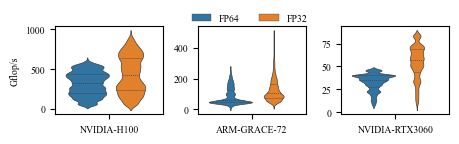

In [17]:
# Propose a base font size of 12 (highly readable for this figure aspect ratio)
font_size = 7

# Update the default font sizes for this figure session
plt.rcParams.update({
    'font.size': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
    'figure.titlesize': font_size
})
melted = merged.melt(id_vars=['System', 'format_name', 'mem_footprint_fp64', 'mem_range_fp64', 'mem_footprint_fp32', 'mem_range_fp32', 'nnz_categ'] + structural_cols, 
                     value_vars=['gflops_fp64', 'gflops_fp32'],
                     var_name='Precision', value_name='GFLOPs')
melted['Precision'] = melted['Precision'].map({'gflops_fp64': 'FP64', 'gflops_fp32': 'FP32'})

ratio = 0.6
fig, axs = plt.subplots(1, len(ranges_dev), figsize=(2.2 * ratio * width, ratio * height))

if len(ranges_dev) == 1:
    axs = [axs]

for i, sys in enumerate(ranges_dev):
    df_sys = melted[melted['System'] == sys]
    
    if not df_sys.empty:
        sns.violinplot(data=df_sys, x='System', y='GFLOPs', hue='Precision', inner='quart', linewidth=0.5, ax=axs[i])
        axs[i].set_xlabel('') 
        # Explicitly set y-axis label and its font size if needed
        axs[i].set_ylabel('Gflop/s', fontsize=font_size)
        if(i>0):
            axs[i].set_ylabel('')
        # Remove the legend from every subplot
        if axs[i].get_legend():
            axs[i].get_legend().remove()

# Extract handles and labels from the first subplot
handles, labels = axs[0].get_legend_handles_labels()

# Place a single legend above all subplots
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.543, 0.87), ncol=2, frameon=False, fontsize=font_size)

plt.tight_layout()
fig_name = './Plots_fp32_vs_fp64/fp64_vs_fp32_gflops.pdf'
plt.savefig(fig_name, bbox_inches='tight')
subprocess.run(['pdfcrop', fig_name], stdout = subprocess.DEVNULL, stderr = subprocess.DEVNULL)
subprocess.run(['mv', fig_name.replace('.pdf', '-crop.pdf'), fig_name])

plt.show()

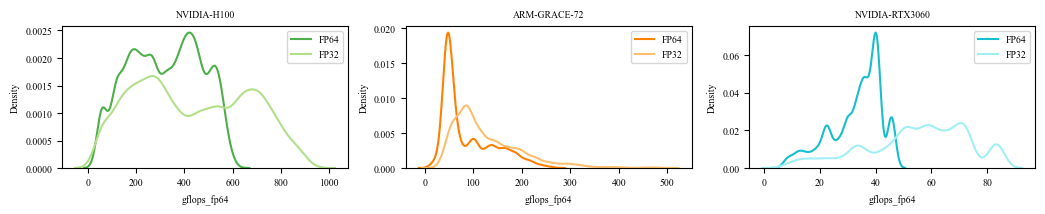

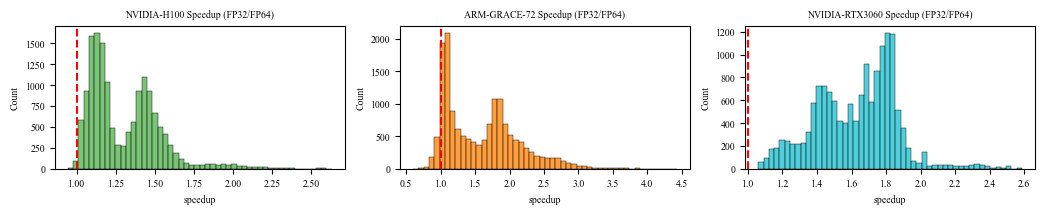

In [6]:
fig, axs = plt.subplots(1, num_systems, figsize=(num_systems*width, height))
for i, sys in enumerate(ranges_dev):
    df = merged[merged['System'] == sys]
    sns.kdeplot(df['gflops_fp64'], ax=axs[i], label='FP64', color=color_dictionary[sys])
    sns.kdeplot(df['gflops_fp32'], ax=axs[i], label='FP32', color=color_dict_fp32[sys])
    axs[i].set_title(sys)
    axs[i].legend()
plt.tight_layout()
plt.savefig('./Plots_fp32_vs_fp64/kde_gflops.pdf', bbox_inches='tight')
plt.show()

fig, axs = plt.subplots(1, num_systems, figsize=(num_systems*width, height))
for i, sys in enumerate(ranges_dev):
    df = merged[merged['System'] == sys]
    sns.histplot(df['speedup'], ax=axs[i], bins=50, color=color_dictionary[sys])
    axs[i].axvline(1.0, color='r', linestyle='--')
    axs[i].set_title(f'{sys} Speedup (FP32/FP64)')
plt.tight_layout()
plt.savefig('./Plots_fp32_vs_fp64/hist_speedup.pdf', bbox_inches='tight')
plt.show()

---
# Structural Feature Breakdown


In [7]:
def print_distribution_col100(feature, ranges_feature, df, name=''):
    ndf_row = [name]
    for val in ranges_feature:
        df_feat = df[df[feature]==val]
        cnt = df_feat.shape[0]
        # new_string = f"{df_feat['gflops_fp64'].median():.2f} / {df_feat['gflops_fp32'].median():.2f}" if cnt > 0 else "N/A"
        # new_string = f"{df_feat['gflops_fp64'].median():.2f} / {df_feat['gflops_fp32'].median():.2f} ({np.round((df_feat['gflops_fp32'].median() - df_feat['gflops_fp64'].median()) / df_feat['gflops_fp64'].median()*100, 2)})" if cnt > 0 else "N/A"
        new_string = f"{df_feat['gflops_fp64'].median():.2f} / {df_feat['gflops_fp32'].median():.2f} ({np.round((df_feat['speedup'].median()), 2)})" if cnt > 0 else "N/A"
        ndf_row.append(new_string)
    return ndf_row

# features = ['nnz_categ', 'anr_categ', 'skew_categ', 'regularity']
# rangess = [nnz_labels, ranges_anr, ranges_skew, ranges_regularity]
features = ['mem_range_fp64', 'nnz_categ', 'anr_categ', 'skew_categ', 'regularity']
rangess = [ranges_memr, nnz_labels, ranges_anr, ranges_skew, ranges_regularity]

for cnt in range(len(features)):
    feat, ranges_feat = features[cnt], rangess[cnt]
    print(f'\n{feat} (FP64 / FP32 medians)')
    new_df_list = []
    
    for system in ranges_dev:
        df_sys = merged[merged['System']==system]
        
        if system == 'ARM-GRACE-72' and feat != 'mem_range_fp64' and feat != 'nnz_categ':
            # Anchor the split using the FP64 footprint
            df_sys_l = df_sys[df_sys['mem_footprint_fp64'] < llc_thresholds[system]]
            new_df_list.append(print_distribution_col100(feat, ranges_feat, df_sys_l, name=f'{system} (<LLC)'))
            
            df_sys_h = df_sys[df_sys['mem_footprint_fp64'] > llc_thresholds[system]]
            new_df_list.append(print_distribution_col100(feat, ranges_feat, df_sys_h, name=f'{system} (>LLC)'))
        else:
            new_df_list.append(print_distribution_col100(feat, ranges_feat, df_sys, name=system))
            
    new_df = pd.DataFrame(new_df_list, columns=['System'] + ranges_feat).set_index('System').T
    display(new_df)



mem_range_fp64 (FP64 / FP32 medians)


System,NVIDIA-H100,ARM-GRACE-72,NVIDIA-RTX3060
[4-8],59.15 / 61.75 (1.04),54.23 / 55.07 (1.01),22.55 / 33.61 (1.48)
[8-16],127.19 / 138.49 (1.1),106.96 / 112.53 (1.05),30.62 / 51.32 (1.68)
[16-32],208.66 / 239.69 (1.16),161.01 / 174.34 (1.09),35.32 / 64.42 (1.8)
[32-64],252.00 / 302.02 (1.18),178.54 / 197.74 (1.12),36.82 / 67.25 (1.77)
[64-128],377.67 / 516.46 (1.33),141.27 / 238.74 (1.8),39.40 / 66.35 (1.74)
[128-256],394.42 / 547.00 (1.37),92.83 / 216.02 (1.83),39.46 / 66.17 (1.74)
[256-512],414.57 / 624.89 (1.42),55.57 / 117.27 (2.1),39.59 / 62.19 (1.69)
[512-1024],419.52 / 621.26 (1.44),47.05 / 87.83 (1.85),38.96 / 56.28 (1.55)
[1024-2048],425.21 / 620.13 (1.44),43.98 / 75.72 (1.78),36.05 / 52.47 (1.45)



nnz_categ (FP64 / FP32 medians)


System,NVIDIA-H100,ARM-GRACE-72,NVIDIA-RTX3060
[0-500K],58.70 / 61.31 (1.04),54.41 / 54.86 (1.01),22.42 / 33.45 (1.49)
[500K-1M],115.36 / 126.49 (1.09),99.27 / 101.65 (1.05),30.02 / 50.10 (1.67)
[1M-10M],201.41 / 232.15 (1.15),152.32 / 165.29 (1.09),35.09 / 60.28 (1.77)
[10M-50M],406.03 / 572.10 (1.4),60.22 / 122.82 (1.98),39.42 / 62.90 (1.71)
[50M-100M],427.42 / 619.68 (1.45),45.18 / 80.26 (1.81),37.50 / 54.53 (1.49)
[100M+],423.74 / 619.43 (1.44),43.71 / 74.64 (1.77),35.60 / 52.36 (1.44)



anr_categ (FP64 / FP32 medians)


System,NVIDIA-H100,ARM-GRACE-72 (<LLC),ARM-GRACE-72 (>LLC),NVIDIA-RTX3060
[0-10],222.08 / 282.04 (1.22),107.73 / 116.52 (1.07),41.26 / 67.23 (1.73),27.18 / 42.40 (1.45)
[10-50],313.11 / 390.80 (1.2),132.16 / 142.33 (1.07),46.31 / 81.38 (1.76),33.93 / 55.04 (1.61)
[50-100],392.65 / 468.32 (1.19),155.29 / 172.35 (1.07),50.88 / 100.12 (1.88),37.82 / 63.94 (1.75)
[100-510],423.40 / 608.21 (1.35),165.77 / 175.87 (1.06),55.29 / 108.80 (1.9),40.87 / 72.34 (1.79)



skew_categ (FP64 / FP32 medians)


System,NVIDIA-H100,ARM-GRACE-72 (<LLC),ARM-GRACE-72 (>LLC),NVIDIA-RTX3060
[0-1.5],171.95 / 191.72 (1.13),134.07 / 138.39 (1.04),97.14 / 307.34 (2.61),34.69 / 59.75 (1.71)
[1.5-50],334.57 / 445.68 (1.27),136.23 / 146.96 (1.06),48.13 / 85.89 (1.76),35.46 / 55.89 (1.65)
[50-250],335.37 / 443.34 (1.26),136.07 / 145.65 (1.06),50.84 / 97.73 (1.91),36.02 / 58.93 (1.69)
[250-3000],346.79 / 450.99 (1.26),130.34 / 140.89 (1.08),48.78 / 89.47 (1.83),36.15 / 57.62 (1.67)
[3000-10000],354.98 / 468.76 (1.31),122.09 / 135.09 (1.09),45.31 / 80.95 (1.78),34.86 / 53.18 (1.57)



regularity (FP64 / FP32 medians)


System,NVIDIA-H100,ARM-GRACE-72 (<LLC),ARM-GRACE-72 (>LLC),NVIDIA-RTX3060
SS,279.39 / 337.94 (1.15),116.62 / 131.15 (1.09),46.20 / 76.36 (1.67),30.39 / 49.89 (1.61)
SL,387.47 / 548.56 (1.37),131.18 / 142.02 (1.07),47.87 / 88.61 (1.88),34.17 / 58.28 (1.71)
LS,371.50 / 540.87 (1.4),139.82 / 147.46 (1.06),51.26 / 96.57 (1.86),37.72 / 59.70 (1.68)
LL,346.62 / 485.97 (1.35),141.91 / 147.72 (1.05),53.73 / 114.90 (1.93),38.31 / 60.11 (1.67)


---
# Speedup per feature range in heatmaps

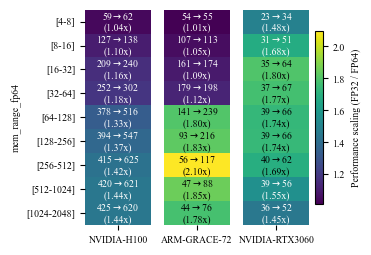

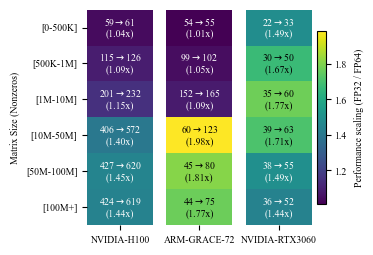

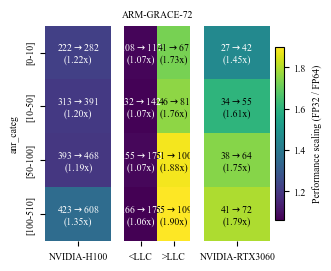

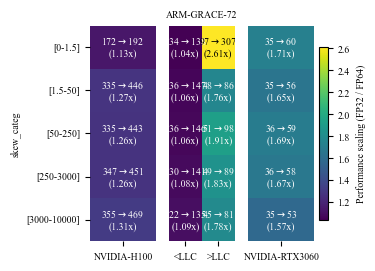

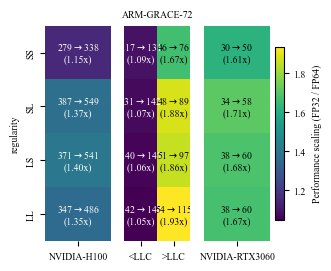

In [8]:
features = ['mem_range_fp64', 'nnz_categ', 'anr_categ', 'skew_categ', 'regularity']
rangess = [ranges_memr, nnz_labels, ranges_anr, ranges_skew, ranges_regularity]
for cnt, feat in enumerate(features):
    ranges_feat = rangess[cnt]
    
    # You might want to slightly increase the vertical multiplier (e.g., 0.6 or 0.7) 
    # to accommodate two lines of text per cell if it looks cramped.
    fig, axs = plt.subplots(1, num_systems, figsize=(width, 1.3 * height))
    
    if num_systems == 1:
        axs = [axs]
        
    # --- PHASE 1: Data preparation and global min/max calculation ---
    all_pivots = []
    all_annot_pivots = []
    
    for system in ranges_dev:
        df_sys = merged[merged['System'] == system]
        heatmap_data = {}
        annot_data = {}
        
        def process_subset(df_sub, col_name):
            speedup_list = []
            text_list = []
            for val in ranges_feat:
                df_feat = df_sub[df_sub[feat] == val]
                if df_feat.shape[0] > 0:
                    med_fp64 = df_feat['gflops_fp64'].median()
                    med_fp32 = df_feat['gflops_fp32'].median()
                    med_speedup = df_feat['speedup'].median()
                    
                    speedup_list.append(med_speedup)
                    # Format as:
                    # FP64 -> FP32
                    # (Speedupx)
                    text_list.append(f"{med_fp64:.0f}$\\rightarrow${med_fp32:.0f}\n({med_speedup:.2f}x)")
                else:
                    speedup_list.append(np.nan)
                    text_list.append("N/A")
                    
            heatmap_data[col_name] = speedup_list
            annot_data[col_name] = text_list

        if system == 'ARM-GRACE-72' and feat not in ['mem_range_fp64', 'nnz_categ']:
            df_sys_l = df_sys[df_sys['mem_footprint_fp64'] < llc_thresholds[system]]
            df_sys_h = df_sys[df_sys['mem_footprint_fp64'] > llc_thresholds[system]]
            
            process_subset(df_sys_l, '<LLC')
            process_subset(df_sys_h, '>LLC')
        else:
            process_subset(df_sys, system)
            
        pivot = pd.DataFrame(heatmap_data, index=ranges_feat)
        annot_pivot = pd.DataFrame(annot_data, index=ranges_feat)
        
        all_pivots.append(pivot)
        all_annot_pivots.append(annot_pivot)
        
    # Calculate the absolute min and max speedup across ALL devices for the color scale
    global_min = min([p.min().min() for p in all_pivots])
    global_max = max([p.max().max() for p in all_pivots])
    
    # --- PHASE 2: Plotting ---
    for col_idx, system in enumerate(ranges_dev):
        ax = axs[col_idx]
        pivot = all_pivots[col_idx]
        annot_pivot = all_annot_pivots[col_idx]
        
        # Apply global vmin/vmax and disable the default individual colorbar
        sns.heatmap(pivot, annot=False, ax=ax, cmap='viridis', vmin=global_min, vmax=global_max, cbar=False)
        
        mesh = ax.collections[0]
        
        # Manual annotation loop 
        for r_idx in range(len(pivot.index)):
            for c_idx in range(len(pivot.columns)):
                val = pivot.iloc[r_idx, c_idx]
                text = annot_pivot.iloc[r_idx, c_idx]
                
                if pd.notna(val):
                    rgba = mesh.cmap(mesh.norm(val))
                    luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                    text_color = 'black' if luminance > 0.5 else 'white'
                else:
                    text_color = 'black'
                
                # Multiline text is handled naturally by ax.text using \n
                ax.text(c_idx + 0.5, r_idx + 0.5, text, ha='center', va='center', fontsize=7, color=text_color, clip_on=True)
        
        if('NVIDIA' not in system):
            ax.set_title(f'{system}', fontsize=7)

        if(feat in ['mem_range_fp64', 'nnz_categ']):
            ax.set_title('')
        ax.set_xlabel('', fontsize=7)
        if (col_idx == 0) and (feat=='nnz_categ'):
            ax.set_ylabel('Matrix Size (Nonzeros)', fontsize=7)
        elif (col_idx == 0):
            ax.set_ylabel(feat, fontsize=7)
        elif (col_idx != 0):
            ax.set_ylabel('')
            ax.set_yticks([])

    # --- PHASE 3: Add the common colorbar ---
    fig.colorbar(mesh, ax=axs, pad=0.02, shrink=0.8, label='Performance scaling (FP32 / FP64)')
        
    fig_name = f'./Plots_fp32_vs_fp64/heatmap_speedup_1D_{feat}.pdf'
    plt.savefig(fig_name, bbox_inches='tight')
    subprocess.run(['pdfcrop', fig_name], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(['mv', fig_name.replace('.pdf', '-crop.pdf'), fig_name])
    plt.show()
    plt.close()

---
# Feature Impact Boxplots

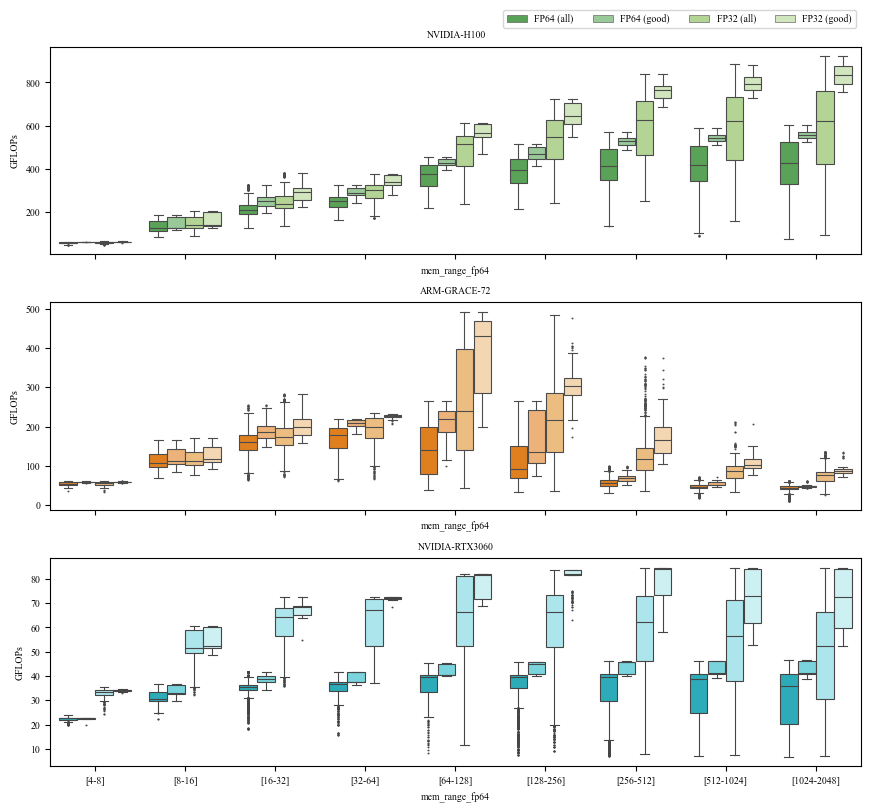

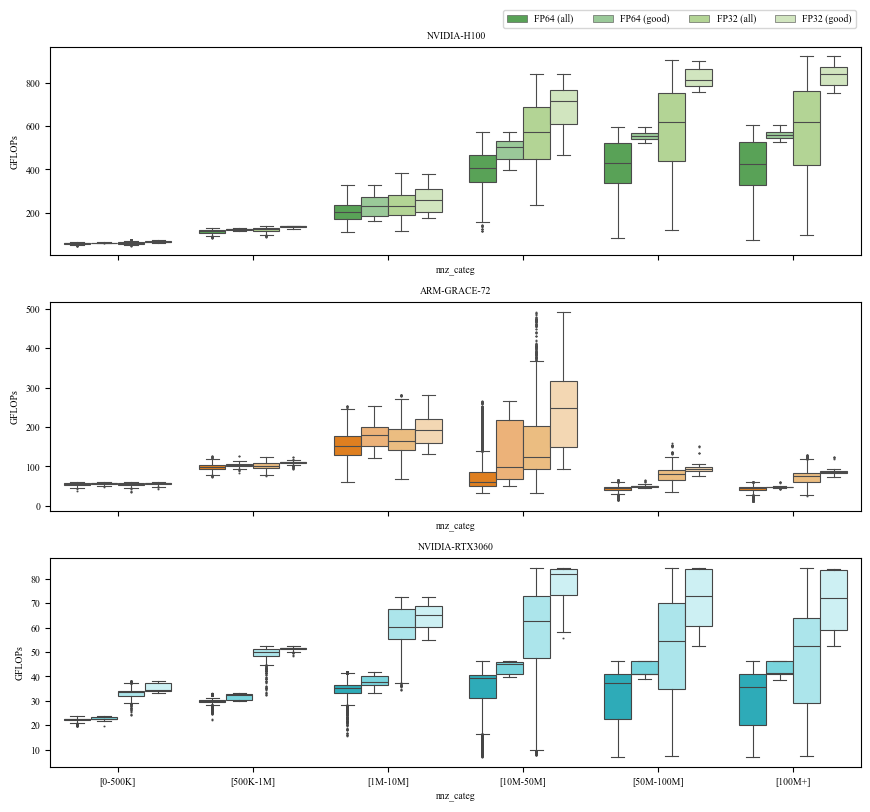

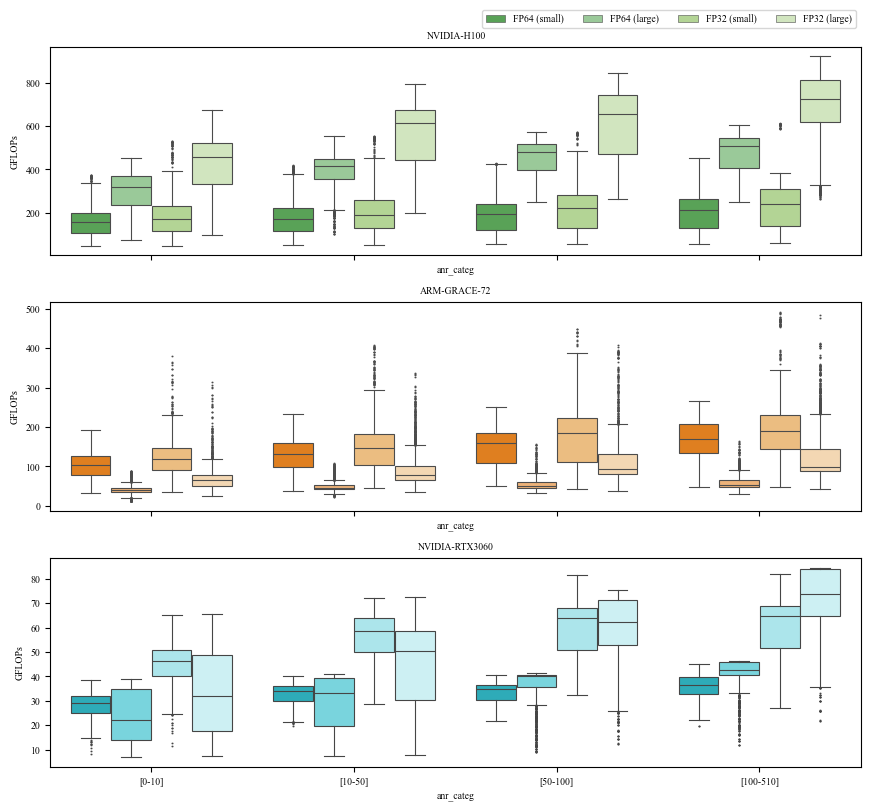

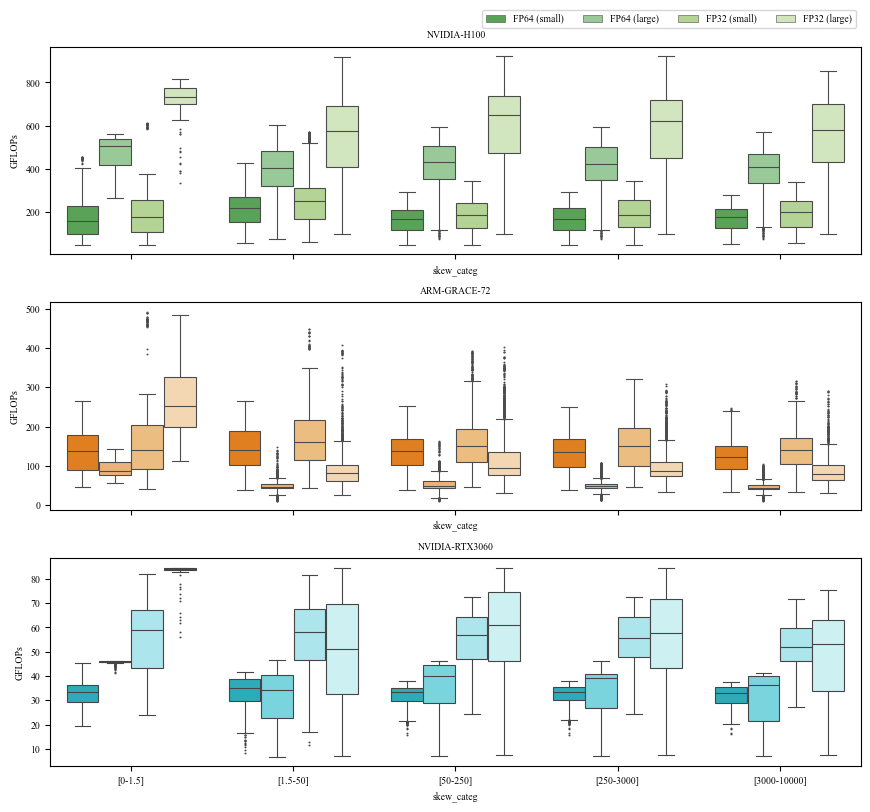

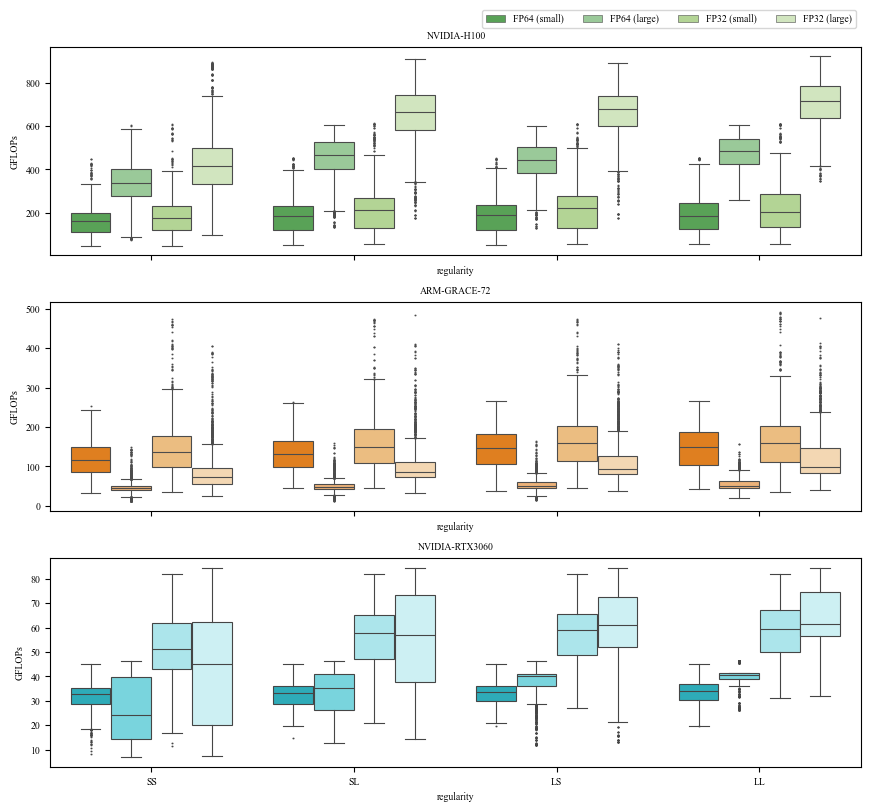

In [9]:
import matplotlib.colors as mc
import colorsys

def lighten_color(color, amount=1.6):
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, 1 - amount * (1 - c[1]))), c[2])

def plot_dev_perf_detailed(feat, df, title, feature_type):
    df_plot = df.copy()
    
    cond_good_nnz = df_plot['avg_nnz_per_row'].between(45, 510)
    cond_good_skew = df_plot['skew'].between(0, 150)
    cond_good_reg = df_plot['regularity'].isin(['LL']) | (df_plot['regularity'].isin(['SL']) & df_plot['mem_range_fp64'].isin(['[32-64]', '[64-128]']))
    cond_good = cond_good_nnz & cond_good_skew & cond_good_reg
    
    llc_grace = llc_thresholds['ARM-GRACE-72']

    ### OLD way to filter... (based on fp64 footprint only)
    # cond_rtx3060_small = (df_plot['System'] == 'NVIDIA-RTX3060') & (df_plot['mem_footprint_fp64'] <= 128)
    # cond_h100_small = (df_plot['System'] == 'NVIDIA-H100') & (df_plot['mem_footprint_fp64'] <= 128)
    # cond_grace_small = (df_plot['System'] == 'ARM-GRACE-72') & (df_plot['mem_footprint_fp64'] <= 1.2 * llc_grace)
    
    # cond_rtx3060_big = (df_plot['System'] == 'NVIDIA-RTX3060') & (df_plot['mem_footprint_fp64'] > 128)
    # cond_h100_big = (df_plot['System'] == 'NVIDIA-H100') & (df_plot['mem_footprint_fp64'] > 128)
    # cond_grace_big = (df_plot['System'] == 'ARM-GRACE-72') & (df_plot['mem_footprint_fp64'] > 1.2 * llc_grace)
    ###
    
    # SMALL: Must fit in cache for the LARGER precision (FP64)
    cond_rtx3060_small = (df_plot['System'] == 'NVIDIA-RTX3060') & (df_plot['mem_footprint_fp64'] <= 128)
    cond_h100_small = (df_plot['System'] == 'NVIDIA-H100') & (df_plot['mem_footprint_fp64'] <= 128)
    cond_grace_small = (df_plot['System'] == 'ARM-GRACE-72') & (df_plot['mem_footprint_fp64'] <= 1.2 * llc_grace)
    
    # BIG: Must spill out of cache for the SMALLER precision (FP32)
    cond_rtx3060_big = (df_plot['System'] == 'NVIDIA-RTX3060') & (df_plot['mem_footprint_fp32'] > 128)
    cond_h100_big = (df_plot['System'] == 'NVIDIA-H100') & (df_plot['mem_footprint_fp32'] > 128)
    cond_grace_big = (df_plot['System'] == 'ARM-GRACE-72') & (df_plot['mem_footprint_fp32'] > 1.2 * llc_grace)

    cond_small = cond_rtx3060_small | cond_h100_small | cond_grace_small
    cond_big = cond_rtx3060_big | cond_h100_big | cond_grace_big

    if feature_type == 'mem':
        df_all = df_plot.copy()
        df_all['Subset'] = 'all'
        
        df_good = df_plot[cond_good].copy()
        df_good['Subset'] = 'good'
        
        df_combined = pd.concat([df_all, df_good])
        subsets = ['all', 'good']
    else:
        df_small = df_plot[cond_small].copy()
        df_small['Subset'] = 'small'
        
        df_large = df_plot[cond_big].copy()
        df_large['Subset'] = 'large'
        
        df_combined = pd.concat([df_small, df_large])
        subsets = ['small', 'large']

    hue_order = [f'FP64 ({subsets[0]})', f'FP64 ({subsets[1]})', f'FP32 ({subsets[0]})', f'FP32 ({subsets[1]})']
    df_combined['Hue_Category'] = df_combined['Precision'] + ' (' + df_combined['Subset'] + ')'
    
    fig, axs = plt.subplots(num_systems, 1, figsize=(width*2.5, height*3.75), sharex=True)

    cat_it = CategoricalDtype(categorical_dict[feat], ordered=True)
    
    for i, sys in enumerate(ranges_dev):
        df_sys = df_combined[df_combined['System'] == sys]
        df_sys[feat] = df_sys[feat].astype(cat_it)
        df_sys = df_sys.sort_values(feat)
        
        c_fp64 = color_dictionary[sys]
        c_fp32 = color_dict_fp32[sys]
        
        palette = {
            f'FP64 ({subsets[0]})': c_fp64,
            f'FP64 ({subsets[1]})': lighten_color(c_fp64, 0.6),
            f'FP32 ({subsets[0]})': c_fp32,
            f'FP32 ({subsets[1]})': lighten_color(c_fp32, 0.6),
        }
        
        sns.boxplot(data=df_sys, x=feat, y='GFLOPs', hue='Hue_Category', ax=axs[i], hue_order=hue_order, palette=palette, fliersize=0.5, linewidth=0.8)
        axs[i].set_title(f'{sys}')
        # axs[i].set_yscale('log')
        
        # Adjust legend to avoid repeating
        if i == 0:
            axs[i].legend(loc='upper right', bbox_to_anchor=(1.0, 1.2), ncol=4)
        else:
            if axs[i].get_legend():
                axs[i].get_legend().remove()
    
    plt.tight_layout()
    plt.savefig(f'./Plots_fp32_vs_fp64/box_{feat}_detailed.pdf', bbox_inches='tight')
    plt.show()

# 'nnz_categ': nnz_labels,
# 'mem_range_fp64': ranges_memr,

categorical_dict = {
    
    'mem_range_fp64': ranges_memr,
    'nnz_categ': nnz_labels,
    'anr_categ': ranges_anr,
    'skew_categ': ranges_skew,
    'regularity': ranges_regularity
}

for feat in features:
    ftype = 'mem' if (feat == 'mem_range_fp64' or feat == 'nnz_categ' ) else 'other'
    # ftype = 'mem' if feat == 'mem_range_fp64' else 'other'
    plot_dev_perf_detailed(feat, melted, feat, ftype)

---
# Scatter Plots: FP64 vs FP32

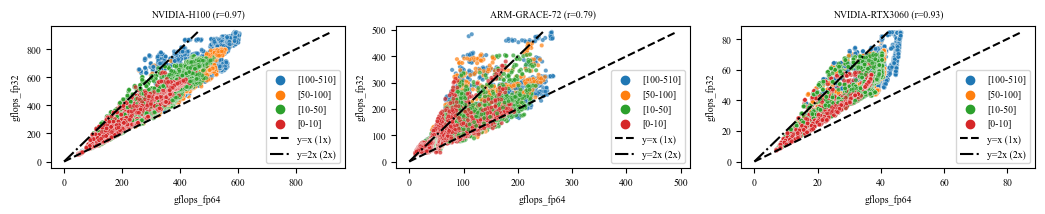

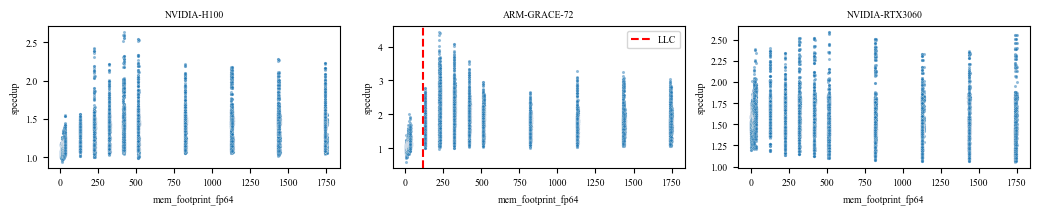

In [10]:
from scipy.stats import pearsonr

fig, axs = plt.subplots(1, num_systems, figsize=(num_systems*width, height))

for i, sys in enumerate(ranges_dev):
    df = merged[merged['System'] == sys]
    r, _ = pearsonr(df['gflops_fp64'], df['gflops_fp32'])

    # sns.scatterplot(data=df, x='gflops_fp64', y='gflops_fp32', ax=axs[i], hue='mem_range', s=10, alpha=0.7)
    sns.scatterplot(data=df, x='gflops_fp64', y='gflops_fp32', ax=axs[i], hue='anr_categ', s=10, alpha=0.7)
    # sns.scatterplot(data=df, x='gflops_fp64', y='gflops_fp32', ax=axs[i], hue='skew_categ', s=10, alpha=0.7)
    # sns.scatterplot(data=df, x='gflops_fp64', y='gflops_fp32', ax=axs[i], hue='regularity', s=10, alpha=0.7)
    
    m_max = max(df['gflops_fp64'].max(), df['gflops_fp32'].max())
    axs[i].plot([0, m_max], [0, m_max], 'k--', label='y=x (1x)')
    # axs[i].plot([0, m_max/2], [0, m_max], 'r:', label='y=2x (2x)')
    axs[i].plot([0, m_max/2], [0, m_max], 'k-.', label='y=2x (2x)')
    
    axs[i].set_title(f'{sys} (r={r:.2f})')
    axs[i].legend()

plt.tight_layout()
plt.savefig('./Plots_fp32_vs_fp64/scatter_gflops.pdf', bbox_inches='tight')
plt.show()

fig, axs = plt.subplots(1, num_systems, figsize=(num_systems*width, height))
for i, sys in enumerate(ranges_dev):
    df = merged[merged['System'] == sys]
    sns.scatterplot(data=df, x='mem_footprint_fp64', y='speedup', ax=axs[i], s=5, alpha=0.5)
    if sys == 'ARM-GRACE-72':
        axs[i].axvline(llc_thresholds[sys], color='r', linestyle='--', label='LLC')
        axs[i].legend()
    axs[i].set_title(f'{sys}')
plt.tight_layout()
plt.savefig('./Plots_fp32_vs_fp64/scatter_mem_speedup.pdf', bbox_inches='tight')
plt.show()

---
# More detailed speedup heatmaps
(x axis: feature, y axis: nnz_categ or mem_range)

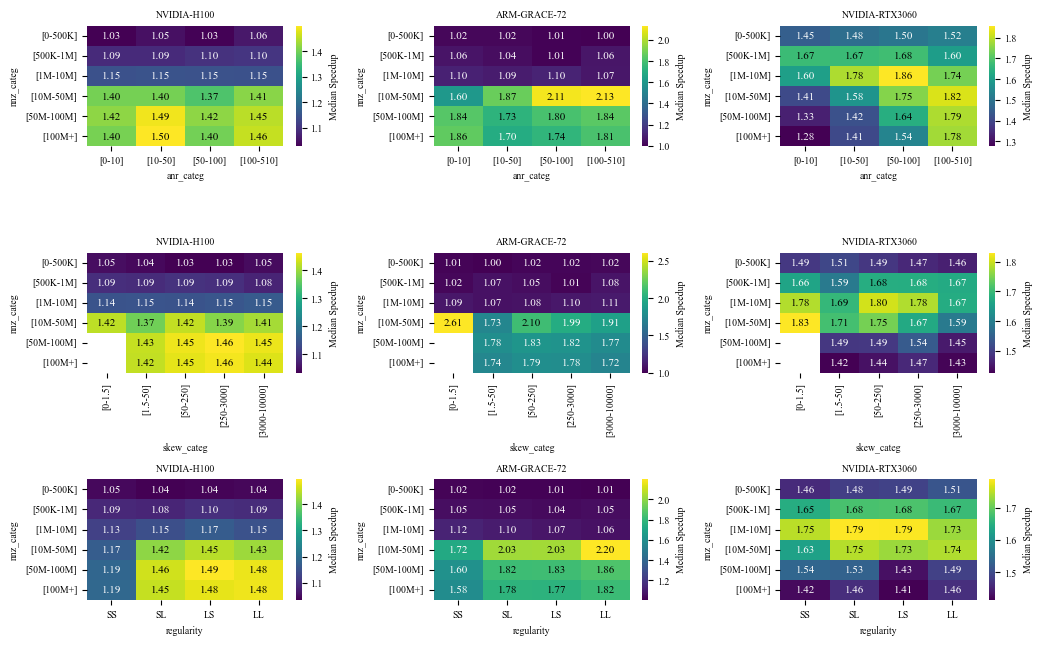

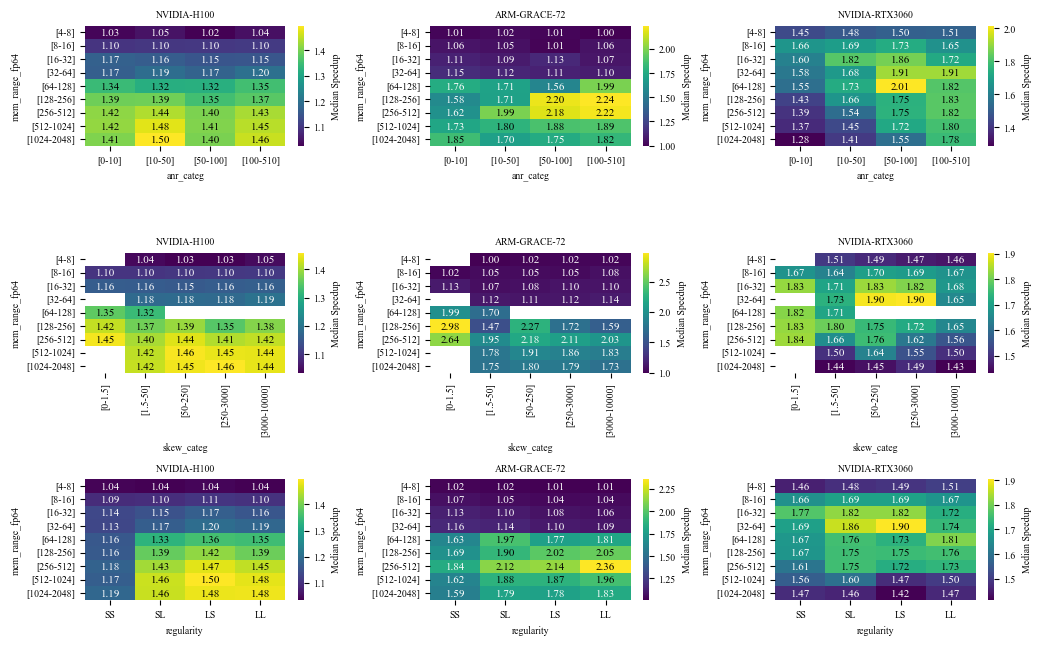

In [11]:
# Define the configurations for each row in the 3x3 grid
row_configs = [
    {'feature': 'anr_categ',  'cols_range': ranges_anr},
    {'feature': 'skew_categ', 'cols_range': ranges_skew},
    {'feature': 'regularity', 'cols_range': ranges_regularity}
]

index_configs = [{'feature': 'nnz_categ', 'rows_range': nnz_labels}, 
                 {'feature': 'mem_range_fp64', 'rows_range': ranges_memr}
]

for index_config in index_configs:
    # Create a figure with 3 rows and 'num_systems' columns
    fig, axs = plt.subplots(3, num_systems, figsize=(num_systems * width, 3 * height))
    
    # Ensure axs is a 2D array in case num_systems is 1
    if num_systems == 1:
        axs = axs.reshape(3, 1)
    
    for row_idx, config in enumerate(row_configs):
        feature = config['feature']
        cols_range = config['cols_range']
        
        for col_idx, sys in enumerate(ranges_dev):
            ax = axs[row_idx, col_idx]
            
            df = merged[merged['System'] == sys]
            
            # Use nnz_categ here so it matches the nnz_labels reindex!
            pivot = df.pivot_table(index=index_config['feature'], columns=feature, values='speedup', aggfunc='median')
            
            # Reorder
            pivot = pivot.reindex(index=index_config['rows_range'], columns=cols_range)
            
            sns.heatmap(pivot, annot=False, ax=ax, cmap='viridis', cbar_kws={'label': 'Median Speedup'})
            
            # Grab the color mapping from the plotted heatmap
            mesh = ax.collections[0]
            
            # Manual annotation loop
            for r_idx in range(len(pivot.index)):
                for c_idx in range(len(pivot.columns)):
                    val = pivot.iloc[r_idx, c_idx]
                    
                    # Format text label (using 2 decimal places for speedup, leave blank if NaN)
                    text = f"{val:.2f}" if pd.notna(val) else ""
                    
                    # Dynamically calculate text color for contrast
                    if pd.notna(val):
                        rgba = mesh.cmap(mesh.norm(val))
                        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                        text_color = 'black' if luminance > 0.5 else 'white'
                    else:
                        text_color = 'black'
                    
                    # Place text centered in the cell with the calculated contrast color
                    ax.text(c_idx + 0.5, r_idx + 0.5, text, ha='center', va='center', fontsize=8, color=text_color, clip_on=True)
                    
            # Set a descriptive title for each subplot so you know which feature is being plotted
            ax.set_title(f'{sys}')
    
    plt.tight_layout()
    plt.savefig(f"./Plots_fp32_vs_fp64/heatmap_combined_speedup_{index_config['feature']}.pdf", bbox_inches='tight')
    plt.show()
    plt.close()

---
# CPU vs GPU Gap

In [12]:
# merged_h100 = merged[merged['System'] == 'NVIDIA-H100']
# merged_rtx = merged[merged['System'] == 'NVIDIA-RTX3060']
# merged_grace = merged[merged['System'] == 'ARM-GRACE-72']

# cross_hg = merged_h100.merge(merged_grace, on=structural_cols, suffixes=('_h100', '_grace'))
# cross_hg['ratio_fp64'] = cross_hg['gflops_fp64_h100'] / cross_hg['gflops_fp64_grace']
# cross_hg['ratio_fp32'] = cross_hg['gflops_fp32_h100'] / cross_hg['gflops_fp32_grace']
# cross_hg['Comparison'] = 'H100 / GRACE'

# cross_rg = merged_rtx.merge(merged_grace, on=structural_cols, suffixes=('_rtx', '_grace'))
# cross_rg['ratio_fp64'] = cross_rg['gflops_fp64_rtx'] / cross_rg['gflops_fp64_grace']
# cross_rg['ratio_fp32'] = cross_rg['gflops_fp32_rtx'] / cross_rg['gflops_fp32_grace']
# cross_rg['Comparison'] = 'RTX3060 / GRACE'

# cross = pd.concat([cross_hg, cross_rg])

# plt.figure(figsize=(width*2, height*1.5))
# sns.ecdfplot(data=cross_hg, x='ratio_fp64', label='FP64 (H100/GRACE)', color='blue')
# sns.ecdfplot(data=cross_hg, x='ratio_fp32', label='FP32 (H100/GRACE)', color='orange')
# sns.ecdfplot(data=cross_rg, x='ratio_fp64', label='FP64 (RTX3060/GRACE)', color='blue', linestyle='--')
# sns.ecdfplot(data=cross_rg, x='ratio_fp32', label='FP32 (RTX3060/GRACE)', color='orange', linestyle='--')
# plt.axvline(1.0, color='r', linestyle=':')
# plt.title('CDF of GPU/CPU Performance Ratio')
# plt.legend()
# plt.savefig('./Plots_fp32_vs_fp64/cdf_gpu_cpu.pdf', bbox_inches='tight')
# plt.show()

# # Thresholds
# thresholds = [0.25, 0.5, 0.75, 0.85, 1.0]
# res = []
# for t in thresholds:
#     val = 1.0 / t
#     pct_fp64_hg = (cross_hg['ratio_fp64'] <= val).mean() * 100
#     pct_fp32_hg = (cross_hg['ratio_fp32'] <= val).mean() * 100
#     pct_fp64_rg = (cross_rg['ratio_fp64'] <= val).mean() * 100
#     pct_fp32_rg = (cross_rg['ratio_fp32'] <= val).mean() * 100
#     res.append({'Threshold (GRACE % of GPU)': f"{t*100}%", 'H100 FP64 (%)': pct_fp64_hg, 'H100 FP32 (%)': pct_fp32_hg, 'RTX FP64 (%)': pct_fp64_rg, 'RTX FP32 (%)': pct_fp32_rg})

# display(pd.DataFrame(res))

# fig, axs = plt.subplots(1, 2, figsize=(width*2.5, height))
# sns.scatterplot(data=cross_hg, x='ratio_fp64', y='ratio_fp32', s=10, alpha=0.5, ax=axs[0])
# m = max(cross_hg['ratio_fp64'].max(), cross_hg['ratio_fp32'].max())
# axs[0].plot([0, m], [0, m], 'k--', label='y=x')
# axs[0].set_xlabel('H100/GRACE Ratio (FP64)')
# axs[0].set_ylabel('H100/GRACE Ratio (FP32)')
# axs[0].set_title('H100/GRACE Ratio shift')
# axs[0].legend()

# sns.scatterplot(data=cross_rg, x='ratio_fp64', y='ratio_fp32', s=10, alpha=0.5, ax=axs[1], color='g')
# m2 = max(cross_rg['ratio_fp64'].max(), cross_rg['ratio_fp32'].max())
# axs[1].plot([0, m2], [0, m2], 'k--', label='y=x')
# axs[1].set_xlabel('RTX3060/GRACE Ratio (FP64)')
# axs[1].set_ylabel('RTX3060/GRACE Ratio (FP32)')
# axs[1].set_title('RTX3060/GRACE Ratio shift')
# axs[1].legend()

# plt.tight_layout()
# plt.savefig('./Plots_fp32_vs_fp64/scatter_gpu_cpu_shift.pdf', bbox_inches='tight')
# plt.show()